In [2]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import joblib
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("../data/leads_dataset.csv")


In [4]:
df.shape

(1000, 13)

In [5]:
df.head()

,name,company,company_size,budget,industry,job_role,engagement_score,email_interaction_score,previous_interactions,demo_requested,previous_purchase,lead_score,priority
0,Amit,Divya Solutions,132,225000.0,Education,C-level,88,68,0,False,True,49.4,Cold
1,Rahul,Rahul Solutions,7,510000.0,Education,Manager,68,26,1,False,False,38.4,Cold
2,Divya,Suresh Group,4484,590000.0,Finance,C-level,79,61,1,False,False,76.7,Warm
3,Rahul,Karan Industries,27,126000.0,Retail,Director,35,36,3,False,False,29.9,Cold
4,Karan,Anjali Solutions,265,729000.0,Education,Director,55,38,3,True,True,76.7,Warm


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   name                     1000 non-null   str    
 1   company                  1000 non-null   str    
 2   company_size             1000 non-null   int64  
 3   budget                   1000 non-null   float64
 4   industry                 1000 non-null   str    
 5   job_role                 1000 non-null   str    
 6   engagement_score         1000 non-null   int64  
 7   email_interaction_score  1000 non-null   int64  
 8   previous_interactions    1000 non-null   int64  
 9   demo_requested           1000 non-null   bool   
 10  previous_purchase        1000 non-null   bool   
 11  lead_score               1000 non-null   float64
 12  priority                 1000 non-null   str    
dtypes: bool(2), float64(2), int64(4), str(5)
memory usage: 88.0 KB


In [7]:
df.isnull().sum()

name                       0
company                    0
company_size               0
budget                     0
industry                   0
job_role                   0
engagement_score           0
email_interaction_score    0
previous_interactions      0
demo_requested             0
previous_purchase          0
lead_score                 0
priority                   0
dtype: int64

structure investigation 

In [8]:
df.shape

(1000, 13)

1.1 structure of non-numerical features

In [9]:
df.select_dtypes(exclude="number").head()

,name,company,industry,job_role,demo_requested,previous_purchase,priority
0,Amit,Divya Solutions,Education,C-level,False,True,Cold
1,Rahul,Rahul Solutions,Education,Manager,False,False,Cold
2,Divya,Suresh Group,Finance,C-level,False,False,Warm
3,Rahul,Karan Industries,Retail,Director,False,False,Cold
4,Karan,Anjali Solutions,Education,Director,True,True,Warm


In [10]:
df.describe(exclude="number")

,name,company,industry,job_role,demo_requested,previous_purchase,priority
count,1000,1000,1000,1000,1000,1000,1000
unique,14,125,7,4,2,2,3
top,Karan,Kavita Solutions,Education,Manager,False,False,Cold
freq,87,19,156,330,622,787,474


1.2 structure of numerical features


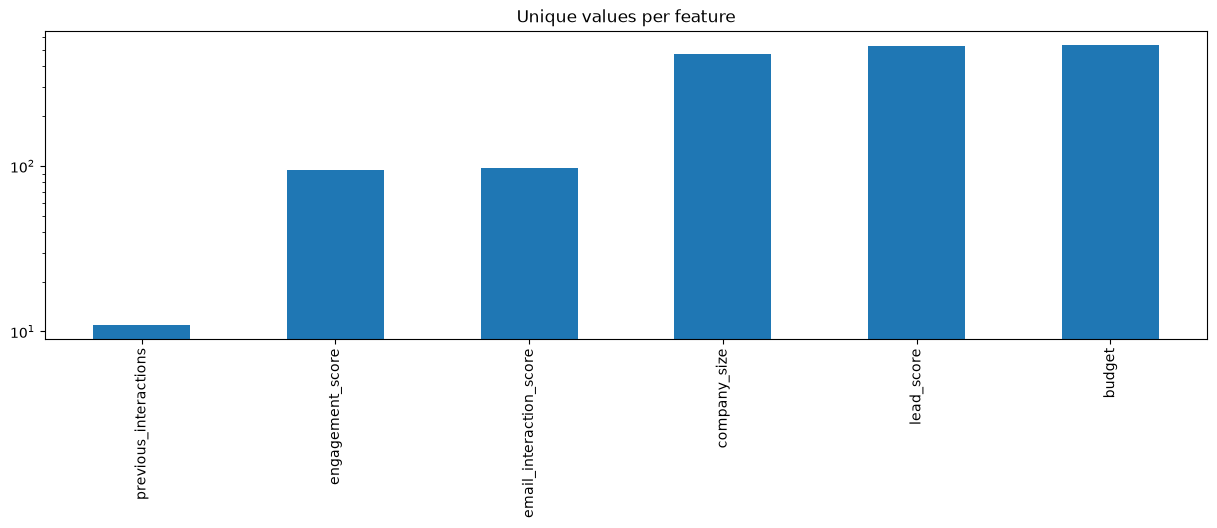

In [11]:
# For each numerical feature compute number of unique entries
unique_values = df.select_dtypes(include="number").nunique().sort_values()

# Plot information with y-axis in log-scale
unique_values.plot.bar(logy=True, figsize=(15, 4), title="Unique values per feature");

2.Quality Investigation

2.1. Duplicates


In [12]:
n_duplicates = df.drop(labels=["job_role"], axis=1).duplicated().sum()
print(f"You seem to have {n_duplicates} duplicates in your database.")

You seem to have 0 duplicates in your database.


2.2 missing values
2.1 per sample

Text(0, 0.5, 'Sample Number')

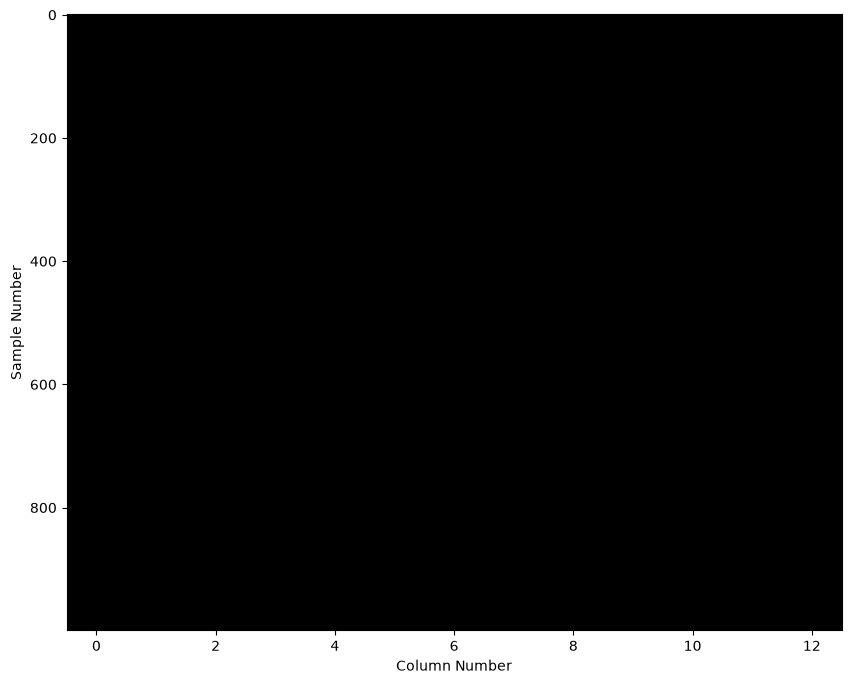

In [13]:
plt.figure(figsize=(10, 8))
plt.imshow(df.isna(), aspect="auto", interpolation="nearest", cmap="gray")
plt.xlabel("Column Number")
plt.ylabel("Sample Number")

In [14]:
%pip install missingno


Note: you may need to restart the kernel to use updated packages.


c:\Users\DELL\lead-scoring-system\.venv\Scripts\python.exe: No module named pip


2.2.2 per feature

<Axes: title={'center': 'Percentage of missing values per feature'}, ylabel='Ratio of missing values per feature'>

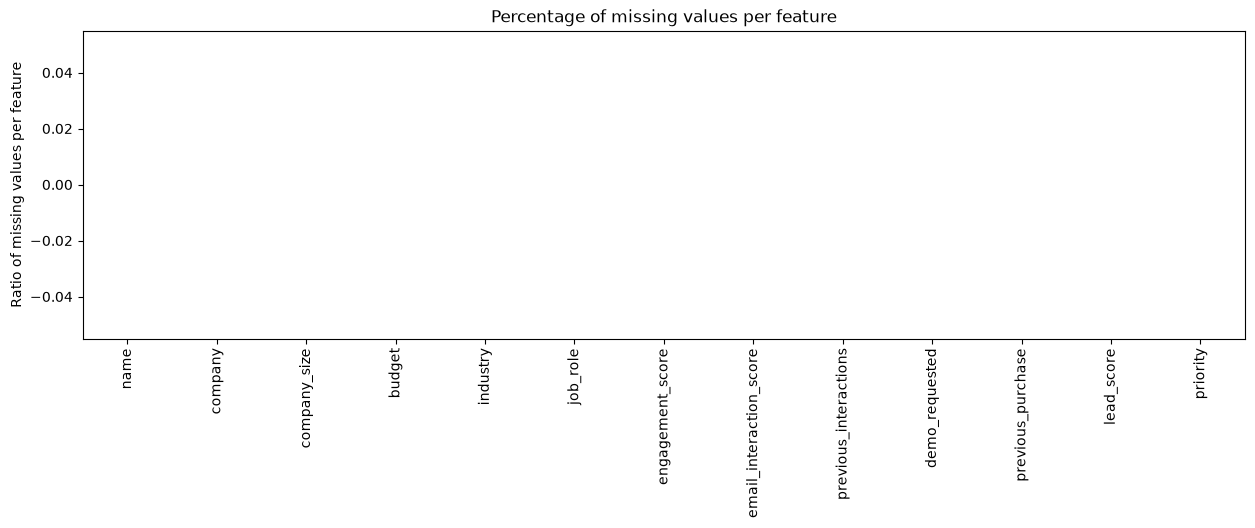

In [15]:
df.isna().mean().sort_values().plot(
    kind="bar", figsize=(15, 4),
    title="Percentage of missing values per feature",
    ylabel="Ratio of missing values per feature")

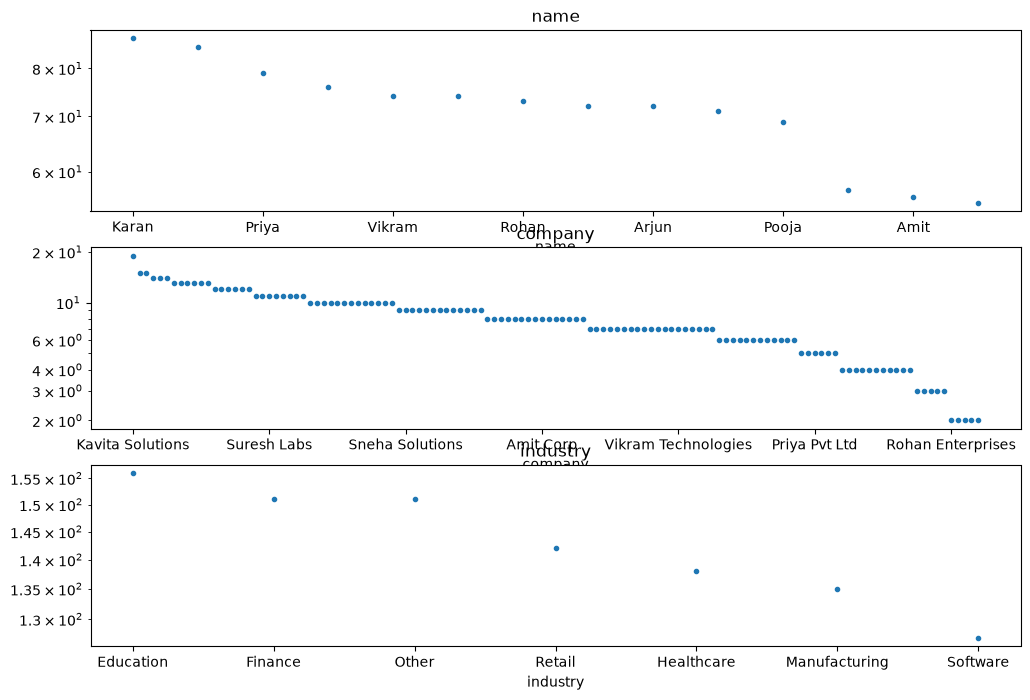

In [16]:
# Create figure object with 3 subplots
fig, axes = plt.subplots(ncols=1, nrows=3, figsize=(12, 8))

# Identify non-numerical features
df_non_numerical = df.select_dtypes(exclude=["number", "datetime"])

# Loop through features and put each subplot on a matplotlib axis object
for col, ax in zip(df_non_numerical.columns, axes.ravel()):

    # Selects one single feature and counts number of occurrences per unique value
    df_non_numerical[col].value_counts().plot(

        # Plots this information in a figure with log-scaled y-axis
        logy=True, title=col, lw=0, marker=".", ax=ax)

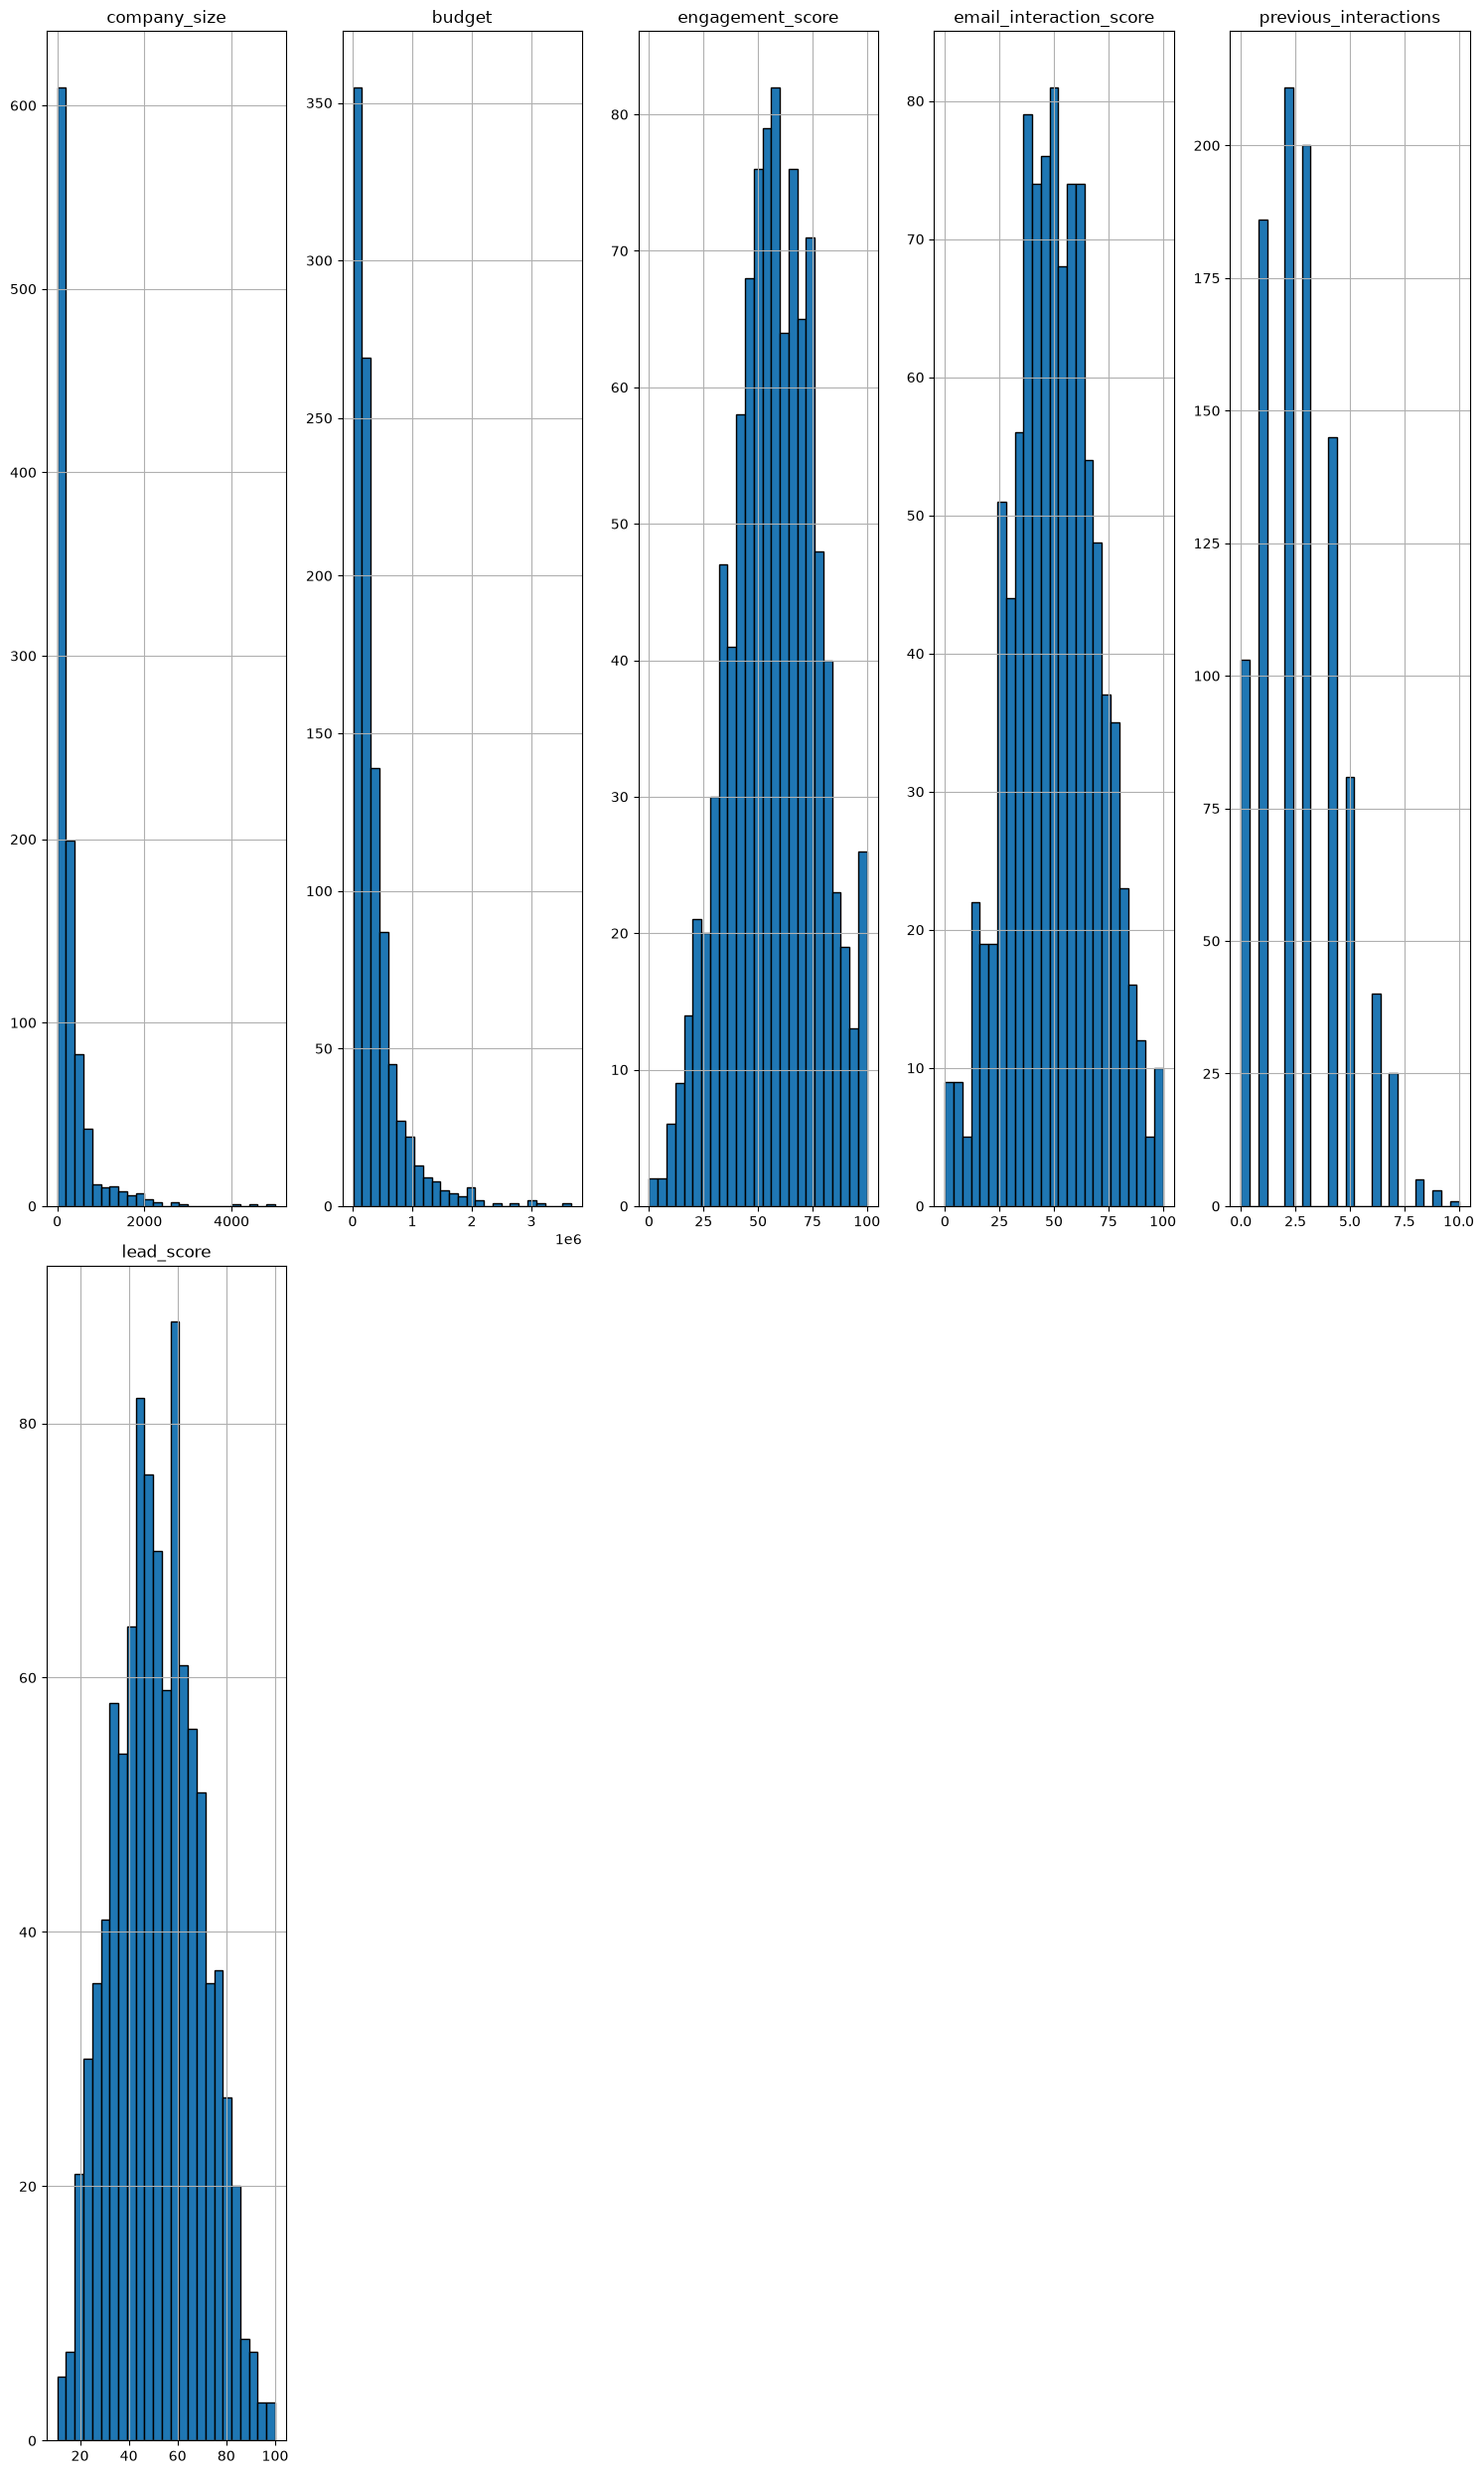

In [17]:
# Plots the histogram for each numerical feature in a separate subplot
df.hist(bins=25, figsize=(15, 25), layout=(-1, 5), edgecolor="black")
plt.tight_layout();

In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import joblib
import warnings
warnings.filterwarnings('ignore')

In [19]:
df = df.drop(columns=["name", "company", "priority"])
df.head()

,company_size,budget,industry,job_role,engagement_score,email_interaction_score,previous_interactions,demo_requested,previous_purchase,lead_score
0,132,225000.0,Education,C-level,88,68,0,False,True,49.4
1,7,510000.0,Education,Manager,68,26,1,False,False,38.4
2,4484,590000.0,Finance,C-level,79,61,1,False,False,76.7
3,27,126000.0,Retail,Director,35,36,3,False,False,29.9
4,265,729000.0,Education,Director,55,38,3,True,True,76.7


In [20]:
le_industry = LabelEncoder()
le_job_role = LabelEncoder()

df["industry_encoded"] = le_industry.fit_transform(df["industry"])
df["job_role_encoded"] = le_job_role.fit_transform(df["job_role"])

df[["industry", "industry_encoded", "job_role", "job_role_encoded"]].head()

,industry,industry_encoded,job_role,job_role_encoded
0,Education,0,C-level,0
1,Education,0,Manager,3
2,Finance,1,C-level,0
3,Retail,5,Director,1
4,Education,0,Director,1


In [21]:
df["demo_requested"] = df["demo_requested"].astype(int)
df["previous_purchase"] = df["previous_purchase"].astype(int)

df.head()

,company_size,budget,industry,job_role,engagement_score,email_interaction_score,previous_interactions,demo_requested,previous_purchase,lead_score,industry_encoded,job_role_encoded
0,132,225000.0,Education,C-level,88,68,0,0,1,49.4,0,0
1,7,510000.0,Education,Manager,68,26,1,0,0,38.4,0,3
2,4484,590000.0,Finance,C-level,79,61,1,0,0,76.7,1,0
3,27,126000.0,Retail,Director,35,36,3,0,0,29.9,5,1
4,265,729000.0,Education,Director,55,38,3,1,1,76.7,0,1


In [22]:
feature_columns = [
    "company_size",
    "budget",
    "industry_encoded",
    "job_role_encoded",
    "engagement_score",
    "email_interaction_score",
    "previous_interactions",
    "demo_requested",
    "previous_purchase",
]

X = df[feature_columns]
y = df["lead_score"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 9)
y shape: (1000,)


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (800, 9)
Test size: (200, 9)


In [24]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained!")

Model trained!


In [25]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"R2 Score: {r2:.3f}")

Mean Absolute Error: 4.84
R2 Score: 0.875


In [26]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42),
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # Cross-validation se aur bharosemand accuracy check karo
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    
    results[name] = {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "CV_R2_mean": cv_scores.mean()
    }
    
    print(f"\n{name}:")
    print(f"  MAE: {mae:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  R2 Score: {r2:.3f}")
    print(f"  Cross-Val R2 (5-fold): {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")


Linear Regression:
  MAE: 6.30
  RMSE: 8.00
  R2 Score: 0.777
  Cross-Val R2 (5-fold): 0.728 (+/- 0.018)

Random Forest:
  MAE: 4.83
  RMSE: 5.97
  R2 Score: 0.876
  Cross-Val R2 (5-fold): 0.870 (+/- 0.014)

Gradient Boosting:
  MAE: 3.71
  RMSE: 4.63
  R2 Score: 0.925
  Cross-Val R2 (5-fold): 0.914 (+/- 0.007)


In [27]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values("R2", ascending=False)
print(results_df)

                        MAE      RMSE        R2  CV_R2_mean
Gradient Boosting  3.714609  4.634106  0.925104    0.913797
Random Forest      4.831722  5.974227  0.875522    0.870027
Linear Regression  6.298089  7.998652  0.776867    0.728383


In [28]:
# Best model choose karo (jo bhi table me sabse upar aaya)
best_model_name = results_df.index[0]
print(f"Best Model: {best_model_name}")

best_model = models[best_model_name]

# Poore data pe retrain karo (train+test dono) taaki final model sabse zyada seekh sake
best_model.fit(X, y)

Best Model: Gradient Boosting


,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, in

                   feature  importance
1                   budget    0.440086
0             company_size    0.201333
4         engagement_score    0.107980
7           demo_requested    0.099788
5  email_interaction_score    0.062533
3         job_role_encoded    0.031293
6    previous_interactions    0.022689
2         industry_encoded    0.018602
8        previous_purchase    0.015695


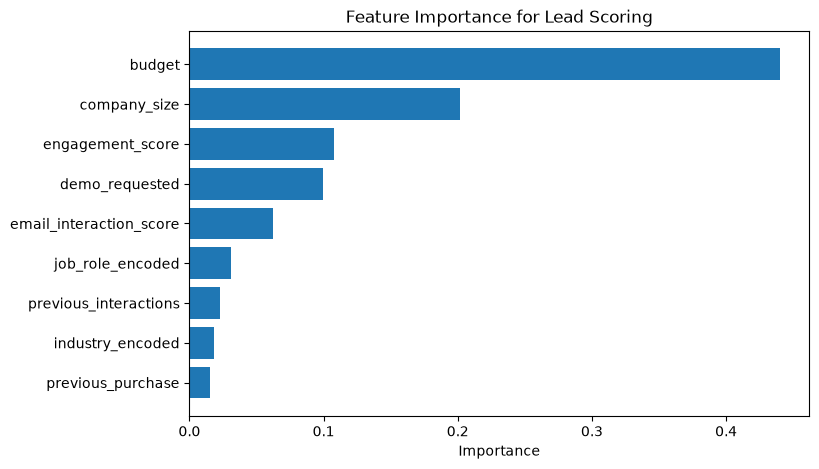

In [29]:
if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'feature': feature_columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print(importance_df)
    
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 5))
    plt.barh(importance_df['feature'], importance_df['importance'])
    plt.xlabel("Importance")
    plt.title("Feature Importance for Lead Scoring")
    plt.gca().invert_yaxis()
    plt.show()

In [30]:
joblib.dump(best_model, "../ml/lead_score_model.pkl")
joblib.dump(le_industry, "../ml/industry_encoder.pkl")
joblib.dump(le_job_role, "../ml/job_role_encoder.pkl")
joblib.dump(feature_columns, "../ml/feature_columns.pkl")

# Model ka naam bhi save karo, taaki baad me pata chale kaunsa model use hua
with open("../ml/model_info.txt", "w") as f:
    f.write(f"Model: {best_model_name}\n")
    f.write(f"R2 Score: {results[best_model_name]['R2']:.3f}\n")
    f.write(f"MAE: {results[best_model_name]['MAE']:.2f}\n")

print(f"'{best_model_name}' model successfully saved!")

'Gradient Boosting' model successfully saved!


In [31]:
if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'feature': feature_columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print(importance_df)

                   feature  importance
1                   budget    0.440086
0             company_size    0.201333
4         engagement_score    0.107980
7           demo_requested    0.099788
5  email_interaction_score    0.062533
3         job_role_encoded    0.031293
6    previous_interactions    0.022689
2         industry_encoded    0.018602
8        previous_purchase    0.015695


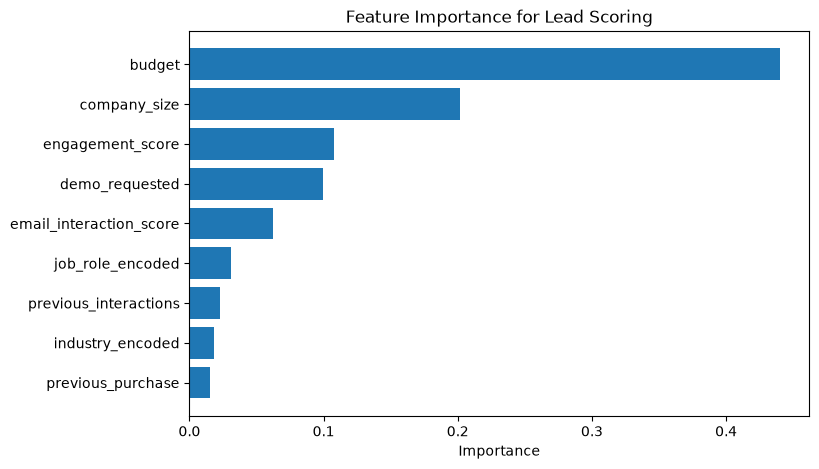

In [32]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel("Importance")
plt.title("Feature Importance for Lead Scoring")
plt.gca().invert_yaxis()
plt.show()

In [33]:
joblib.dump(best_model, "../ml/lead_score_model.pkl")
joblib.dump(le_industry, "../ml/industry_encoder.pkl")
joblib.dump(le_job_role, "../ml/job_role_encoder.pkl")
joblib.dump(feature_columns, "../ml/feature_columns.pkl")

with open("../ml/model_info.txt", "w") as f:
    f.write(f"Model: {best_model_name}\n")
    f.write(f"R2 Score: {results[best_model_name]['R2']:.3f}\n")
    f.write(f"MAE: {results[best_model_name]['MAE']:.2f}\n")

print(f"'{best_model_name}' model successfully saved!")

'Gradient Boosting' model successfully saved!


In [34]:
print(df["industry"].unique)

<bound method Series.unique of 0      Education
1      Education
2        Finance
3         Retail
4      Education
         ...    
995      Finance
996       Retail
997       Retail
998        Other
999      Finance
Name: industry, Length: 1000, dtype: str>


In [37]:
print(df["lead_score"].max())

100.0


In [38]:
print(df["lead_score"].min())

10.7


In [44]:
print(df["lead_score"].min())
print(df["lead_score"].max())
print((df["lead_score"]>=80).sum())
print(len(df))
print(df["industry"].unique())
print(df["job_role"].unique())
print(df[df["lead_score"]>=80][["company_size","budget","engagement_score","demo_requested"]].describe())

10.7
100.0
56
1000
<StringArray>
[    'Education',       'Finance',        'Retail',      'Software',
         'Other', 'Manufacturing',    'Healthcare']
Length: 7, dtype: str
<StringArray>
['C-level', 'Manager', 'Director', 'Individual Contributor']
Length: 4, dtype: str
       company_size        budget  engagement_score  demo_requested
count     56.000000  5.600000e+01         56.000000       56.000000
mean     649.142857  7.643036e+05         77.017857        0.821429
std      695.342909  4.426358e+05         15.996012        0.386459
min       74.000000  2.140000e+05         46.000000        0.000000
25%      270.250000  4.772500e+05         66.500000        1.000000
50%      467.000000  6.535000e+05         77.000000        1.000000
75%      742.250000  9.265000e+05         89.250000        1.000000
max     4073.000000  2.978000e+06        100.000000        1.000000


In [45]:
print(df["email_interaction_score"].describe())

count    1000.000000
mean       49.634000
std        19.561152
min         0.000000
25%        37.000000
50%        49.000000
75%        63.000000
max       100.000000
Name: email_interaction_score, dtype: float64
